# Laboratorio 2. Deep Learning para Series de Tiempo

## Similitud de las series con catch22

**CC3084 - Data Science - UVG - Semestre II 2026**

**Autor:** Fernando Hernández - 23645

Se explora la similitud entre las siete series mensuales construidas en el
Laboratorio 1 (total, tres regiones y tres fronteras) usando las 22
características del algoritmo **catch22**, sobre la serie completa de 210 meses
(`series_mensuales.csv`, salida de la etapa 5 del pipeline del Laboratorio 1).

### ¿Cuál es la idea detrás de catch22? (2.1)

catch22 (*CAnonical Time-series CHaracteristics*) nace del proyecto *hctsa*,
que reunió más de 7,000 características calculables sobre una serie de tiempo.
Fulcher, Little y Jones evaluaron ese catálogo sobre cientos de problemas de
clasificación y encontraron que la gran mayoría de características son
redundantes entre sí; catch22 es el subconjunto de **22 características
canónicas** que conserva casi todo el poder discriminativo del catálogo
completo siendo órdenes de magnitud más barato de calcular.

Cada característica resume un aspecto distinto de la dinámica de la serie:
distribución de los valores (colas, asimetría), autocorrelación lineal y no
lineal, periodicidad, escalamiento de las fluctuaciones, transiciones entre
valores consecutivos y conteos de eventos extremos, entre otros. El resultado
es que **cualquier serie, sin importar su largo o su escala, queda representada
por un vector de 22 números comparables**.

Su importancia práctica: convierte el problema de "¿qué tan parecidas son dos
series?" —difícil de responder mirando gráficas— en un problema de distancia
entre vectores, sobre el que se pueden aplicar herramientas estándar (PCA,
clustering, mapas de distancia). También permite usar la dinámica de una serie
como insumo de modelos de aprendizaje, que es lo que se hace en el punto 2.14.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pycatch22
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform, pdist

SEED = 23645
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (11, 4)

## 1. Carga de las siete series

Las series se usan completas (enero 2009 a junio 2026): aquí no se pronostica,
se caracteriza la dinámica, y truncar en 2021 escondería la recuperación
pospandemia que es parte de la identidad de cada serie.

['total', 'region: América Del Centro', 'region: América Del Norte', 'region: Europa', 'frontera: La Aurora', 'frontera: Valle Nuevo', 'frontera: San Cristóbal']
210 meses, 2009-01 a 2026-06


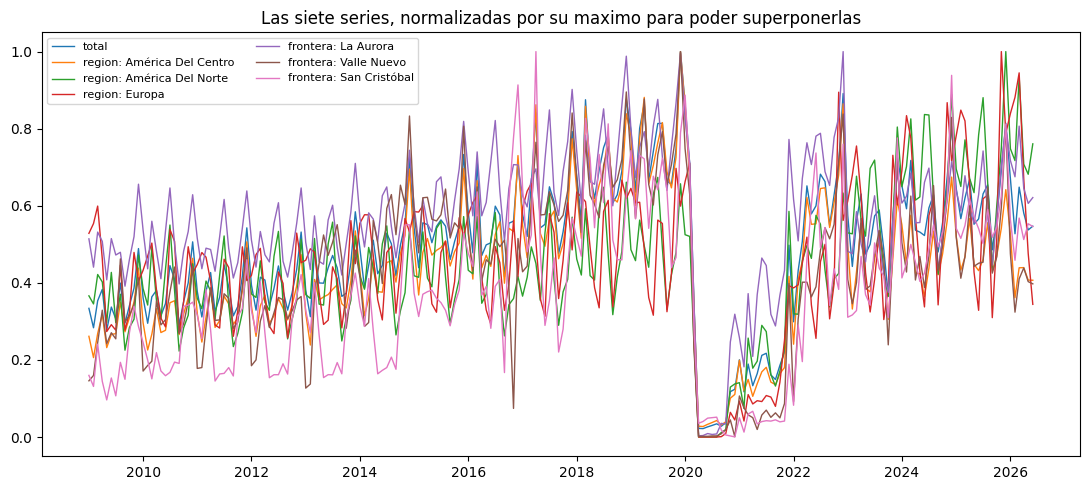

In [2]:
series = pd.read_csv("../data/processed/series_mensuales.csv",
                     parse_dates=["fecha"]).set_index("fecha")
print(series.columns.tolist())
print(f"{len(series)} meses, {series.index.min():%Y-%m} a {series.index.max():%Y-%m}")

fig, ax = plt.subplots(figsize=(11, 5))
for col in series.columns:
    ax.plot(series.index, series[col] / series[col].max(), lw=1, label=col)
ax.set_title("Las siete series, normalizadas por su maximo para poder superponerlas")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 2. Extracción de las 22 características y matriz series × características (2.2, 2.3)

`pycatch22` recibe cada serie como lista y devuelve los 22 valores con sus
nombres. La matriz resultante tiene una fila por serie y una columna por
característica.

In [3]:
filas = {}
for col in series.columns:
    res = pycatch22.catch22_all(series[col].tolist())
    filas[col] = dict(zip(res["names"], res["values"]))

matriz = pd.DataFrame(filas).T
print(f"matriz: {matriz.shape[0]} series x {matriz.shape[1]} caracteristicas")
matriz.round(3)

matriz: 7 series x 22 caracteristicas


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
total,0.083,0.342,8.965,3.0,0.352,-0.062,0.933,30.0,0.014,11.0,...,0.056,0.210,0.324,0.820,6.0,1.852,0.833,0.857,0.123,0.626
region: América Del Centro,0.391,0.128,8.866,3.0,0.400,-0.065,0.919,42.0,0.014,7.0,...,0.056,0.171,0.324,0.815,6.0,1.833,0.786,0.857,0.123,0.635
region: América Del Norte,0.311,-0.239,9.077,2.0,0.271,-0.012,0.943,12.0,0.036,3.0,...,0.038,0.829,0.324,0.740,5.0,2.053,0.167,0.738,0.098,0.722
region: Europa,0.268,0.008,4.448,2.0,0.348,0.084,0.943,8.0,0.014,8.0,...,0.059,0.819,0.333,0.762,6.0,2.055,0.143,0.738,0.172,0.783
frontera: La Aurora,-0.401,-0.118,6.602,10.0,0.204,-0.163,0.947,34.0,0.010,11.0,...,0.071,0.188,0.324,0.759,5.0,2.001,0.857,0.857,0.172,0.738
frontera: Valle Nuevo,0.312,0.075,9.212,2.0,0.265,-0.092,0.923,38.0,0.039,7.0,...,0.056,0.162,0.329,0.792,6.0,1.854,0.143,0.833,0.123,0.655
frontera: San Cristóbal,0.584,-0.116,8.497,7.0,0.345,-0.046,0.871,31.0,0.070,7.0,...,0.048,0.200,-0.414,0.788,5.0,1.750,0.143,0.857,0.123,0.693


## 3. Estandarización (2.4)

Las características viven en escalas incomparables (unas son correlaciones en
[-1, 1], otras conteos o períodos). Antes de cualquier análisis comparativo se
estandariza cada columna a media 0 y desviación 1 (z-score), para que ninguna
domine las distancias solo por su escala.

In [4]:
escalador = StandardScaler()
matriz_z = pd.DataFrame(escalador.fit_transform(matriz),
                        index=matriz.index, columns=matriz.columns)
matriz_z.round(2)

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
total,-0.48,1.85,0.61,-0.39,0.64,-0.16,0.31,0.18,-0.71,1.29,...,0.09,-0.55,0.40,1.36,0.87,-0.56,1.18,0.72,-0.41,-1.25
region: América Del Centro,0.59,0.65,0.55,-0.39,1.41,-0.20,-0.28,1.18,-0.71,-0.28,...,0.09,-0.68,0.40,1.18,0.87,-0.72,1.03,0.72,-0.41,-1.09
region: América Del Norte,0.31,-1.40,0.68,-0.74,-0.66,0.55,0.70,-1.33,0.41,-1.85,...,-1.74,1.60,0.40,-1.52,-1.15,1.24,-0.81,-1.56,-1.36,0.54
region: Europa,0.16,-0.02,-2.12,-0.74,0.57,1.93,0.70,-1.66,-0.70,0.11,...,0.44,1.56,0.44,-0.74,0.87,1.26,-0.88,-1.56,1.50,1.67
frontera: La Aurora,-2.15,-0.73,-0.82,2.02,-1.74,-1.60,0.90,0.51,-0.88,1.29,...,1.79,-0.62,0.40,-0.86,-1.15,0.77,1.25,0.72,1.50,0.83
frontera: Valle Nuevo,0.31,0.36,0.76,-0.74,-0.75,-0.59,-0.08,0.85,0.52,-0.28,...,0.09,-0.72,0.42,0.35,0.87,-0.53,-0.88,0.26,-0.41,-0.70
frontera: San Cristóbal,1.25,-0.71,0.33,0.99,0.53,0.07,-2.24,0.26,2.07,-0.28,...,-0.76,-0.58,-2.45,0.21,-1.15,-1.47,-0.88,0.72,-0.41,0.00


## 4. Análisis de la matriz (2.5)

### 4.1 Análisis de Componentes Principales (PCA)

varianza explicada por componente: PC1: 33.9%, PC2: 29.1%, PC3: 21.5%, PC4: 10.4%


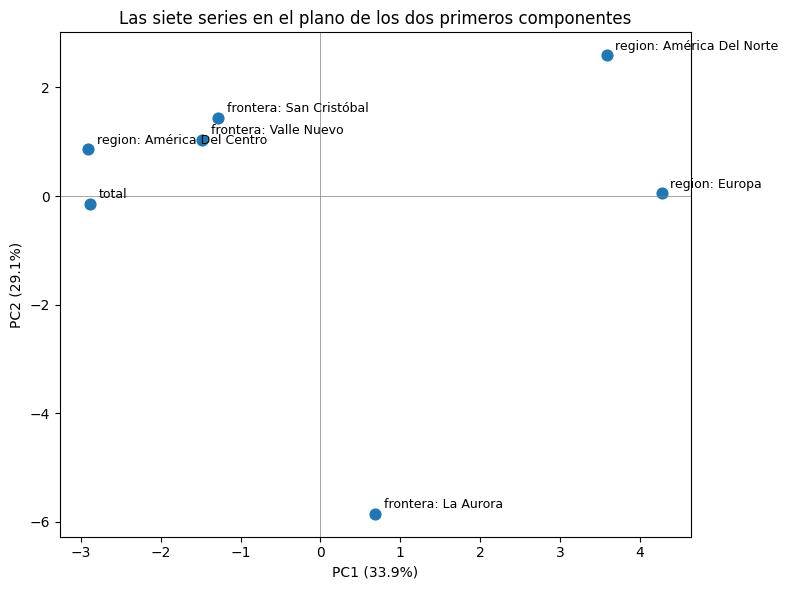

In [5]:
pca = PCA()
comps = pca.fit_transform(matriz_z)
var = pca.explained_variance_ratio_

print("varianza explicada por componente:",
      ", ".join(f"PC{i+1}: {v:.1%}" for i, v in enumerate(var[:4])))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(comps[:, 0], comps[:, 1], s=60)
for i, nombre in enumerate(matriz_z.index):
    ax.annotate(nombre, (comps[i, 0], comps[i, 1]),
                fontsize=9, xytext=(6, 4), textcoords="offset points")
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel(f"PC1 ({var[0]:.1%})")
ax.set_ylabel(f"PC2 ({var[1]:.1%})")
ax.set_title("Las siete series en el plano de los dos primeros componentes")
plt.tight_layout()
plt.show()

In [6]:
cargas = pd.DataFrame(pca.components_[:2].T, index=matriz_z.columns,
                      columns=["PC1", "PC2"])
print("caracteristicas con mayor carga absoluta en PC1:")
print(cargas["PC1"].abs().sort_values(ascending=False).head(6).round(3).to_string())
print()
print("caracteristicas con mayor carga absoluta en PC2:")
print(cargas["PC2"].abs().sort_values(ascending=False).head(6).round(3).to_string())

caracteristicas con mayor carga absoluta en PC1:
FC_LocalSimple_mean3_stderr               0.334
DN_OutlierInclude_p_001_mdrmd             0.332
SP_Summaries_welch_rect_area_5_1          0.332
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1    0.330
SB_BinaryStats_mean_longstretch1          0.327
SB_MotifThree_quantile_hh                 0.321

caracteristicas con mayor carga absoluta en PC2:
DN_HistogramMode_5                         0.359
FC_LocalSimple_mean1_tauresrat             0.354
SP_Summaries_welch_rect_centroid           0.301
PD_PeriodicityWang_th0_01                  0.300
CO_FirstMin_ac                             0.299
IN_AutoMutualInfoStats_40_gaussian_fmmi    0.299


### 4.2 Clustering

Se usa clustering jerárquico con enlace de Ward sobre la matriz estandarizada
(el dendrograma muestra cómo se van fusionando las series) y se contrasta con
k-means, eligiendo el número de grupos por el coeficiente de silueta.

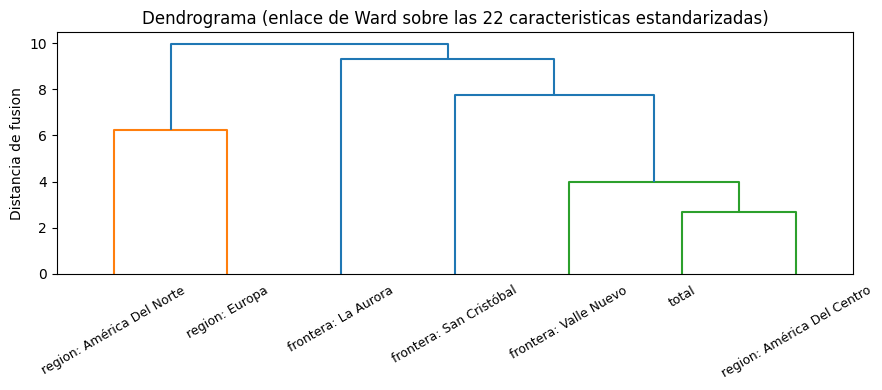

k=2: silueta = 0.207
   grupo 0: region: América Del Norte, region: Europa
   grupo 1: total, region: América Del Centro, frontera: La Aurora, frontera: Valle Nuevo, frontera: San Cristóbal
k=3: silueta = 0.247
   grupo 0: total, region: América Del Centro, frontera: Valle Nuevo, frontera: San Cristóbal
   grupo 1: region: América Del Norte, region: Europa
   grupo 2: frontera: La Aurora
k=4: silueta = 0.253
   grupo 0: region: América Del Norte, region: Europa
   grupo 1: total, region: América Del Centro, frontera: Valle Nuevo
   grupo 2: frontera: San Cristóbal
   grupo 3: frontera: La Aurora


In [7]:
enlace = linkage(matriz_z.values, method="ward")

fig, ax = plt.subplots(figsize=(9, 4))
dendrogram(enlace, labels=matriz_z.index.tolist(), ax=ax,
           leaf_rotation=30, leaf_font_size=9)
ax.set_title("Dendrograma (enlace de Ward sobre las 22 caracteristicas estandarizadas)")
ax.set_ylabel("Distancia de fusion")
plt.tight_layout()
plt.show()

for k in (2, 3, 4):
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED).fit(matriz_z.values)
    sil = silhouette_score(matriz_z.values, km.labels_)
    grupos = {c: [s for s, l in zip(matriz_z.index, km.labels_) if l == c]
              for c in range(k)}
    print(f"k={k}: silueta = {sil:.3f}")
    for c, miembros in grupos.items():
        print(f"   grupo {c}: {', '.join(miembros)}")

### 4.3 Mapa de calor de las características

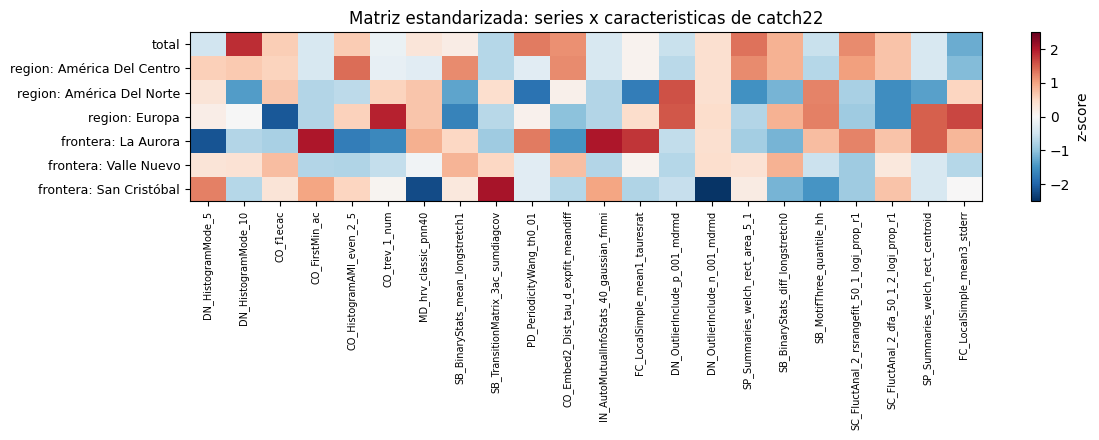

In [8]:
fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.imshow(matriz_z.values, cmap="RdBu_r", vmin=-2.5, vmax=2.5, aspect="auto")
ax.set_xticks(range(len(matriz_z.columns)))
ax.set_xticklabels(matriz_z.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(matriz_z.index)))
ax.set_yticklabels(matriz_z.index, fontsize=9)
fig.colorbar(im, label="z-score")
ax.set_title("Matriz estandarizada: series x caracteristicas de catch22")
plt.tight_layout()
plt.show()

### 4.4 Matriz de correlaciones entre características

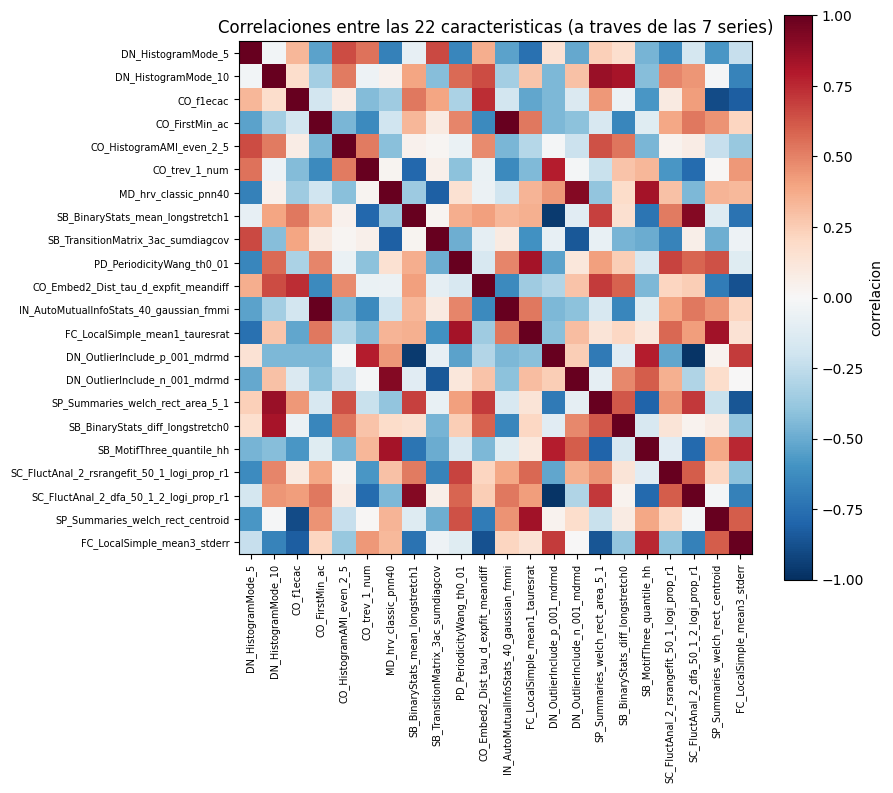

pares de caracteristicas mas correlacionados:
CO_FirstMin_ac                        IN_AutoMutualInfoStats_40_gaussian_fmmi    1.00
DN_OutlierInclude_p_001_mdrmd         SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1    -0.98
SB_BinaryStats_mean_longstretch1      DN_OutlierInclude_p_001_mdrmd             -0.96
                                      SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1     0.92
MD_hrv_classic_pnn40                  DN_OutlierInclude_n_001_mdrmd              0.92
CO_f1ecac                             SP_Summaries_welch_rect_centroid          -0.89
CO_Embed2_Dist_tau_d_expfit_meandiff  FC_LocalSimple_mean3_stderr               -0.87
DN_HistogramMode_10                   SP_Summaries_welch_rect_area_5_1           0.86


In [9]:
corr = matriz_z.corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.columns, fontsize=7)
fig.colorbar(im, label="correlacion")
ax.set_title("Correlaciones entre las 22 caracteristicas (a traves de las 7 series)")
plt.tight_layout()
plt.show()

pares = (corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))
         .stack().sort_values(key=np.abs, ascending=False))
print("pares de caracteristicas mas correlacionados:")
print(pares.head(8).round(2).to_string())

### 4.5 Mapa de distancias entre series

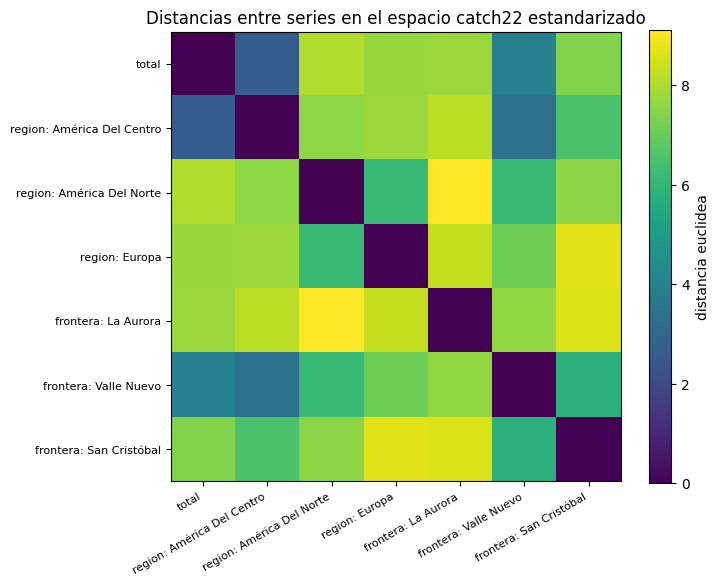

pares de series mas cercanos:
total                       region: América Del Centro    2.67
region: América Del Centro  frontera: Valle Nuevo         3.44
total                       frontera: Valle Nuevo         3.97
frontera: Valle Nuevo       frontera: San Cristóbal       5.87
region: América Del Norte   frontera: Valle Nuevo         6.15
                            region: Europa                6.21
region: América Del Centro  frontera: San Cristóbal       6.50
region: Europa              frontera: Valle Nuevo         7.11
total                       frontera: San Cristóbal       7.39
region: América Del Norte   frontera: San Cristóbal       7.53
region: América Del Centro  region: América Del Norte     7.58
frontera: La Aurora         frontera: Valle Nuevo         7.63
total                       region: Europa                7.71
                            frontera: La Aurora           7.73
region: América Del Centro  region: Europa                7.76
total                    

In [10]:
dist = pd.DataFrame(squareform(pdist(matriz_z.values)),
                    index=matriz_z.index, columns=matriz_z.index)

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(dist.values, cmap="viridis")
ax.set_xticks(range(len(dist)))
ax.set_xticklabels(dist.columns, rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(len(dist)))
ax.set_yticklabels(dist.index, fontsize=8)
fig.colorbar(im, label="distancia euclidea")
ax.set_title("Distancias entre series en el espacio catch22 estandarizado")
plt.tight_layout()
plt.show()

print("pares de series mas cercanos:")
pares_d = (dist.where(np.triu(np.ones_like(dist, dtype=bool), k=1)).stack()
           .sort_values())
print(pares_d.round(2).to_string())

## 5. Análisis e interpretación (2.6 a 2.13)

### 2.7 ¿Cuáles series presentan comportamientos más similares?

Las tres representaciones cuentan la misma historia. El par más cercano en el
mapa de distancias es **total y América Del Centro** (distancia 2.67, la
siguiente más corta es 3.44), y en el plano PC1-PC2 aparecen prácticamente
superpuestas; el dendrograma las fusiona primero. Le siguen **América Del
Centro con Valle Nuevo** (3.44) y **total con Valle Nuevo** (3.97). Tiene
lógica de negocio: América Del Centro es la región que domina el total de
visitantes, y Valle Nuevo es una frontera terrestre cuyo tráfico es
mayoritariamente centroamericano, así que las tres series comparten el mismo
motor subyacente.

### 2.8 ¿Qué características fueron las más importantes para diferenciar las series?

Los dos primeros componentes explican el 63% de la varianza (33.9% + 29.1%) y
sus cargas señalan dos ejes de diferenciación:

- **PC1 — suavidad y persistencia de la serie:** `FC_LocalSimple_mean3_stderr`
  (error de un predictor local simple, es decir qué tan rugosa es la serie),
  `DN_OutlierInclude_p_001_mdrmd` (cómo se reparten en el tiempo los valores
  extremos), `SP_Summaries_welch_rect_area_5_1` (potencia espectral de baja
  frecuencia, el peso de la tendencia), la proporción DFA
  (`SC_FluctAnal_..._prop_r1`) y las rachas largas sobre la media
  (`SB_BinaryStats_mean_longstretch1`). Separa las series suaves y persistentes
  de las más erráticas.
- **PC2 — escala temporal de la memoria y periodicidad:** `DN_HistogramMode_5`,
  `FC_LocalSimple_mean1_tauresrat`, el centroide espectral, la periodicidad de
  Wang (`PD_PeriodicityWang_th0_01`), el primer mínimo de la autocorrelación
  (`CO_FirstMin_ac`) y la auto-información mutua. Separa las series según qué
  tan marcado y a qué plazo es su ciclo anual.

### 2.9 ¿Existen grupos naturales de series?

Sí. El dendrograma y k-means (mejor silueta en k=3-4, alrededor de 0.25)
coinciden en tres grupos:

1. **{total, América Del Centro, Valle Nuevo, San Cristóbal}** — el bloque
   centroamericano-terrestre: crecimiento alto, pico en diciembre y dinámica
   dominada por el flujo regional (San Cristóbal se separa como subgrupo en
   k=4, pero se une a este bloque antes que a cualquier otro).
2. **{América Del Norte, Europa}** — los mercados lejanos: estacionalidad
   anual muy fuerte con picos propios (julio y marzo), crecimiento prepandemia
   bajo y paro total en 2020.
3. **{La Aurora}** — un clúster de una sola serie: la vía aérea no se parece
   lo suficiente a nada más.

### 2.10 ¿Las series de una misma categoría tienden a agruparse?

No. Las categorías del enunciado **no** coinciden con los grupos dinámicos:
las tres fronteras quedan repartidas (La Aurora aislada; Valle Nuevo y San
Cristóbal con el bloque centroamericano) y las tres regiones también (América
Del Centro con el total y las fronteras terrestres; Norte y Europa entre sí).
Lo que agrupa a las series no es la categoría administrativa sino el **tipo de
viajero que las alimenta**: flujo regional terrestre por un lado, mercados
lejanos estacionales por otro, y el aeropuerto como caso propio.

### 2.11 ¿Cuál es la serie más atípica?

**La Aurora.** Es la única serie que forma clúster propio desde k=3, su vecino
más cercano está a 7.63 (más lejos que el vecino más cercano de cualquier otra
serie; compárese con el 2.67 de total-Centro) y en el PCA queda sola en su
cuadrante. La justificación está en su naturaleza: es la única serie puramente
aérea, con un perfil estacional propio (turismo internacional y visitas
familiares, no cruce fronterizo cotidiano), un cierre pandémico más largo que
las fronteras terrestres y una recuperación pospandemia acelerada que la llevó
muy por encima de su nivel de 2019, rompiendo la forma que la serie traía. Esa
combinación de suavidad, memoria larga y quiebre estructural no la comparte
ninguna otra serie del conjunto.

### 2.12 Comparación con el análisis exploratorio del Laboratorio 1

Los agrupamientos son consistentes con el EDA:

- **Estacionalidad:** el EDA midió fuerza estacional de 0.91-0.92 en Norte y
  Europa contra 0.74-0.79 en Centro y el total; catch22 junta exactamente a las
  dos series hiperestacionales (vía las características de periodicidad de
  PC2), con picos anuales propios (julio y marzo contra diciembre).
- **Tendencia:** el bloque centroamericano concentra los CAGR prepandemia
  altos (8-10% anual) mientras Norte y Europa crecían 2-4%; el eje PC1
  (potencia de baja frecuencia, rachas sobre la media) recoge esa diferencia.
- **Volatilidad:** los coeficientes de variación del EDA (0.31-0.36 el bloque
  centroamericano, 0.24-0.28 los mercados lejanos) van en el mismo sentido que
  la separación por rugosidad de PC1.
- **Pandemia:** las series que el EDA marcó con caída de -100% y recuperación
  rápida sobre 2019 (Norte 139%, Europa 125%) quedan juntas; las de
  recuperación lenta (Centro 66%) quedan en el otro bloque. El bloque de ceros
  de 2020 alimenta directamente las características de valores extremos
  (`DN_OutlierInclude`) que cargan fuerte en PC1.
- **Autocorrelación:** las ACF del Laboratorio 1 mostraban ciclo anual marcado
  en todas las series pero con decaimientos distintos; `CO_FirstMin_ac`,
  la auto-información mutua y la periodicidad de Wang capturan esas mismas
  diferencias de escala temporal y son las que ordenan PC2.

### 2.13 Tres descubrimientos que el análisis exploratorio no hacía evidentes

1. **El total es dinámicamente redundante con América Del Centro** (distancia
   2.67, la mitad de la siguiente). El EDA mostraba que Centro pesa mucho en el
   total, pero catch22 cuantifica que sus dinámicas son casi la misma serie:
   modelar el total equivale, en la práctica, a modelar Centro más ruido.
2. **La pertenencia a una categoría no implica similitud dinámica:** Valle
   Nuevo está más cerca de una región (América Del Centro, 3.44) que de su
   compañera de categoría La Aurora (7.63). Mirando las gráficas por categoría,
   como se hizo en el EDA, esa afinidad cruzada no se veía.
3. **Buena parte de las 22 características se mueven juntas en este conjunto:**
   el primer mínimo de la ACF y la auto-información mutua correlacionan 1.00, y
   la distribución temporal de extremos correlaciona -0.98 con la proporción
   DFA, porque el bloque de ceros de la pandemia arrastra varias características
   a la vez. En la práctica, la identidad de cada serie se resume en los dos o
   tres ejes que muestran los primeros componentes (PC1-PC3 acumulan 84%), no
   en 22 dimensiones independientes.

Los tres hallazgos tienen consecuencia directa para el modelado: sugieren
priorizar series representativas de cada grupo en lugar de repetir esfuerzo en
series casi duplicadas, y anticipan que un modelo que funcione para el bloque
centroamericano no se traslada a La Aurora, que es justamente la serie que se
modela por separado en este laboratorio.